# 🎵 Audio Event Detection — Evaluation
Đánh giá model đã train với `best_model.pth`

## 1. Setup & Imports

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import yaml
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

# ── Project root ──
PROJECT_ROOT = Path("../").resolve()   # chỉnh nếu notebook ở thư mục khác
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

from models.ast_model import AudioSpectrogramTransformer
from utils.dataset import create_data_loaders
from utils.metrics import MetricsCalculator

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

print("✓ All imports OK")

Project root: D:\Desktop\PAIDS\audio_event_detection
✓ All imports OK


## 2. Config

In [2]:
# ── Chỉnh các đường dẫn ở đây ──
CONFIG_PATH      = PROJECT_ROOT / "configs" / "config.yaml"
CHECKPOINT_PATH  = PROJECT_ROOT / "models"/ "checkpoints" / "best_model.pth"
METADATA_PATH    = PROJECT_ROOT / "data" / "processed" / "spectrograms" / "processed_metadata.csv"
RESULTS_DIR      = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Load config ──
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Đọc số class thực tế từ processed_metadata.csv
import pandas as pd
_meta_check = pd.read_csv(METADATA_PATH)
_meta_check = _meta_check.dropna(subset=['label'])
NUM_CLASSES = int(_meta_check['label'].nunique())
print(f"Classes (từ data): {NUM_CLASSES}")
print(_meta_check['target_class'].value_counts().to_string())

# Thứ tự theo label 0,1,2,... trong processed_metadata.csv
_label_map = (
    _meta_check[['label','target_class']]
    .drop_duplicates()
    .sort_values('label')
)
CLASS_NAMES = _label_map['target_class'].tolist()
print(f"\nCLASS_NAMES: {CLASS_NAMES}")

Device : cpu
Classes (từ data): 7
target_class
normal            8309
dog_bark           999
siren              929
gunshot            374
explosion           40
fire_crackling      40
scream              40

CLASS_NAMES: ['gunshot', 'explosion', 'siren', 'scream', 'dog_bark', 'fire_crackling', 'normal']


## 3. Load Model

In [ ]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

model = AudioSpectrogramTransformer(str(CONFIG_PATH))

state_dict = checkpoint["model_state_dict"]

if all(k.startswith("module.") for k in state_dict.keys()):
    print("Detected DataParallel checkpoint → stripping 'module.' prefix")
    state_dict = {k[len("module."):]: v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"✓ Model loaded from epoch : {checkpoint.get('epoch', '?')}")
print(f"  Saved Val F1            : {checkpoint.get('metrics', {}).get('f1_score', '?')}")

Detected DataParallel checkpoint → stripping 'module.' prefix
✓ Model loaded from epoch : 56
  Saved Val F1            : 0.6670871493916797


## 4. Load Data

In [ ]:
import pandas as pd

metadata = pd.read_csv(METADATA_PATH)
print("Đường dẫn gốc:", metadata['feature_path'].iloc[0])

def fix_path(p):
    p = Path(p)
    if not p.is_absolute():
        return str(PROJECT_ROOT / p)
    return str(p)

metadata['feature_path'] = metadata['feature_path'].apply(fix_path)
print("Đường dẫn sau fix:", metadata['feature_path'].iloc[0])

# Kiểm tra file có tồn tại không
sample = metadata['feature_path'].iloc[0]
print("File tồn tại:", Path(sample).exists())

Đường dẫn gốc: data/processed/spectrograms/00000_dog_bark.npy
Đường dẫn sau fix: D:\Desktop\PAIDS\audio_event_detection\data\processed\spectrograms\00000_dog_bark.npy
File tồn tại: True


In [5]:
from utils.dataset import AudioEventDataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

batch_size   = config['training']['batch_size']
num_workers  = config['hardware']['num_workers']
pin_memory   = config['hardware']['pin_memory']

# Xóa samples lỗi nhãn (giống 02_model_analysis.ipynb)
metadata = metadata.dropna(subset=['label'])
metadata['label'] = metadata['label'].astype(int)

# Dùng ĐÚNG cách split của 02_model_analysis.ipynb
# 80% train / 10% val / 10% test, random_state=42, stratify
train_df, temp_df = train_test_split(
    metadata, test_size=0.2, random_state=42, stratify=metadata['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

test_dataset = AudioEventDataset(test_df, str(CONFIG_PATH), mode='test')
test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=num_workers,
                          pin_memory=pin_memory)

print(f"Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")

Train : 8,584 | Val : 1,073 | Test : 1,074


## 5. Evaluate Function

In [6]:
def evaluate(loader, split_name="test"):
    criterion         = nn.CrossEntropyLoss()
    metrics_calc      = MetricsCalculator(NUM_CLASSES)
    running_loss      = 0.0
    all_predictions   = []
    all_targets       = []
    all_probabilities = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc=f"Evaluating [{split_name}]"):
            inputs  = inputs.to(device)
            targets = targets.to(device).squeeze(-1)

            outputs       = model(inputs)
            loss          = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)
            predictions   = torch.argmax(outputs, dim=1)

            running_loss      += loss.item()
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    targets_arr = np.array(all_targets)
    preds_arr   = np.array(all_predictions)
    probs_arr   = np.array(all_probabilities)

    metrics = metrics_calc.calculate_metrics(targets_arr, preds_arr, probs_arr)
    metrics["loss"] = running_loss / len(loader)

    return metrics, targets_arr, preds_arr, probs_arr

## 6. Run Evaluation

In [7]:
# Đổi thành val_loader hoặc train_loader nếu muốn
metrics, targets, predictions, probs = evaluate(test_loader, split_name="test")

Evaluating [test]: 100%|██████████| 34/34 [05:09<00:00,  9.10s/it]

## 7. Overall Metrics

In [8]:
print("=" * 45)
print("  EVALUATION RESULTS — TEST SET")
print("=" * 45)
print(f"  Loss      : {metrics['loss']:.4f}")
print(f"  Accuracy  : {metrics.get('accuracy', 0):.4f}")
print(f"  F1 Score  : {metrics.get('f1_score', 0):.4f}")
print(f"  Precision : {metrics.get('precision', 0):.4f}")
print(f"  Recall    : {metrics.get('recall', 0):.4f}")
if "auc_roc" in metrics:
    print(f"  AUC-ROC   : {metrics['auc_roc']:.4f}")
print("=" * 45)

  EVALUATION RESULTS — TEST SET
  Loss      : 0.1923
  Accuracy  : 0.9413
  F1 Score  : 0.7072
  Precision : 0.7985
  Recall    : 0.6643


## 8. Per-class Report

In [9]:
print(classification_report(targets, predictions, target_names=CLASS_NAMES, digits=4))

                precision    recall  f1-score   support

       gunshot     0.9189    0.8947    0.9067        38
     explosion     0.5000    0.2500    0.3333         4
         siren     0.8925    0.8925    0.8925        93
        scream     0.5000    0.2500    0.3333         4
      dog_bark     0.8108    0.9000    0.8531       100
fire_crackling     1.0000    0.5000    0.6667         4
        normal     0.9674    0.9627    0.9650       831

      accuracy                         0.9413      1074
     macro avg     0.7985    0.6643    0.7072      1074
  weighted avg     0.9412    0.9413    0.9404      1074



## 9. Confusion Matrix

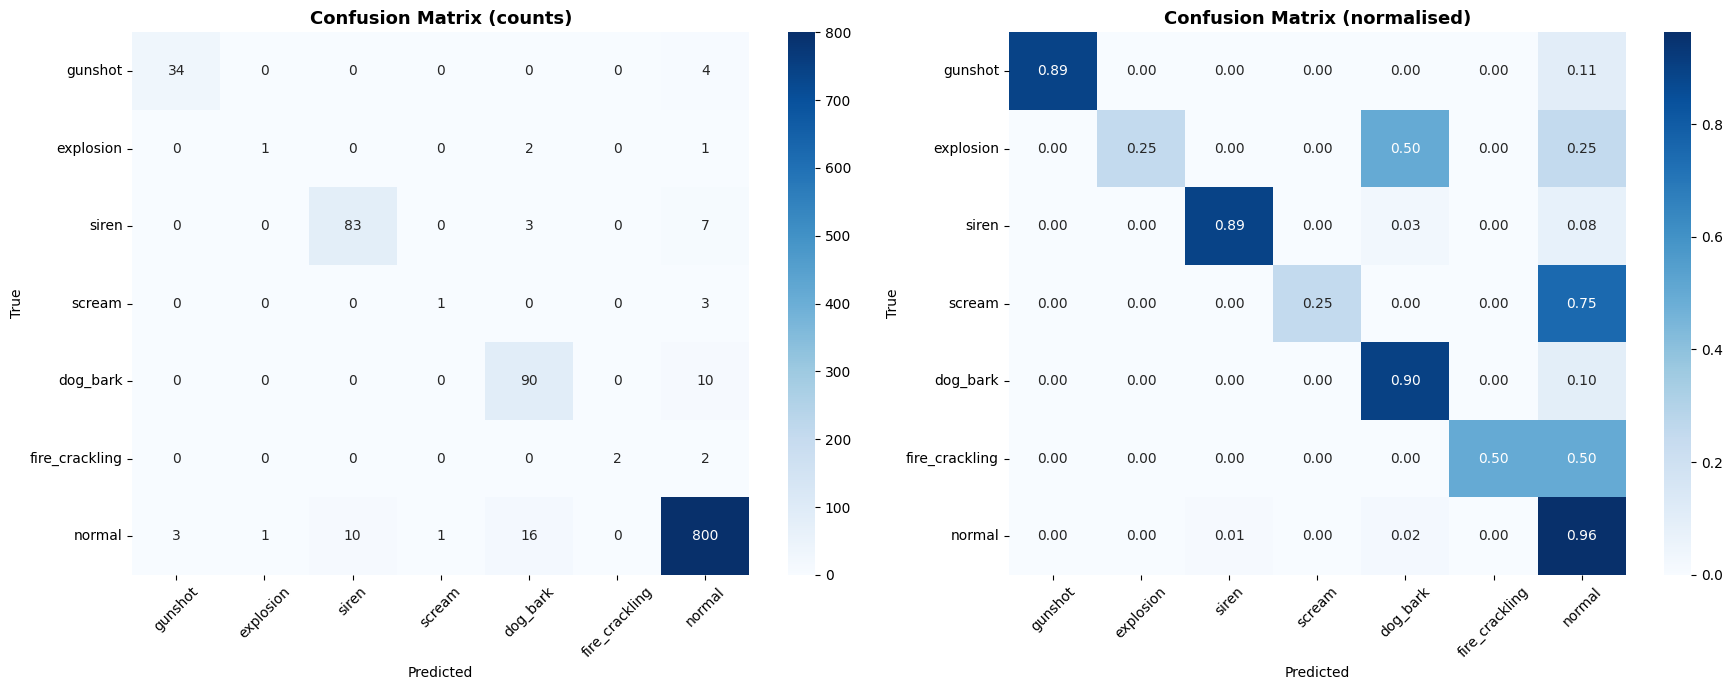

✓ Saved → D:\Desktop\PAIDS\audio_event_detection\results\confusion_matrix.png


In [10]:
cm      = confusion_matrix(targets, predictions)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=45)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalised)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved → {save_path}")

## 10. Per-class F1 Bar Chart

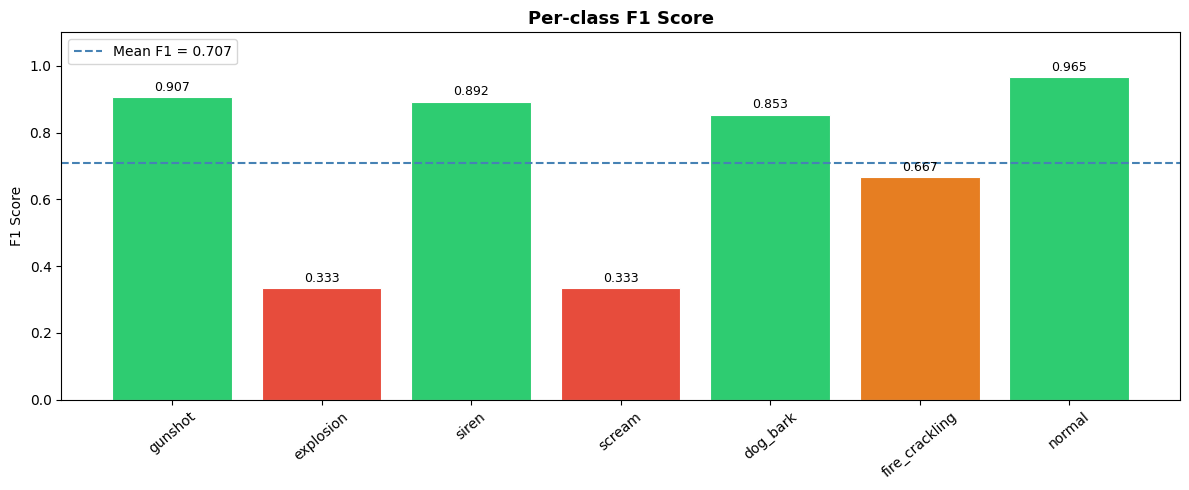

✓ Saved → D:\Desktop\PAIDS\audio_event_detection\results\per_class_f1.png


In [11]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(targets, predictions, average=None)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if f >= 0.8 else "#e67e22" if f >= 0.6 else "#e74c3c" for f in per_class_f1]
bars = ax.bar(CLASS_NAMES, per_class_f1, color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.axhline(y=metrics.get("f1_score", 0), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Mean F1 = {metrics.get('f1_score', 0):.3f}")
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 Score", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=40)
ax.legend()
plt.tight_layout()

save_path = RESULTS_DIR / "per_class_f1.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved → {save_path}")

## 11. Save Metrics to JSON

In [12]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = RESULTS_DIR / f"eval_test_{timestamp}.json"

serialisable = {k: float(v) if isinstance(v, (np.floating, float)) else v
                for k, v in metrics.items()}
serialisable["checkpoint"] = str(CHECKPOINT_PATH)
serialisable["per_class_f1"] = {cls: float(f1) for cls, f1 in zip(CLASS_NAMES, per_class_f1)}

with open(save_path, "w") as f:
    json.dump(serialisable, f, indent=2)

print(f"✓ Metrics saved → {save_path}")
print(json.dumps(serialisable, indent=2))

✓ Metrics saved → D:\Desktop\PAIDS\audio_event_detection\results\eval_test_20260405_010525.json
{
  "accuracy": 0.9413407821229051,
  "precision": 0.7985078174647937,
  "recall": 0.6642722154168466,
  "f1_score": 0.7072245401556019,
  "precision_Class_0": 0.918918918918919,
  "recall_Class_0": 0.8947368421052632,
  "f1_Class_0": 0.9066666666666666,
  "precision_Class_1": 0.5,
  "recall_Class_1": 0.25,
  "f1_Class_1": 0.3333333333333333,
  "precision_Class_2": 0.8924731182795699,
  "recall_Class_2": 0.8924731182795699,
  "f1_Class_2": 0.8924731182795699,
  "precision_Class_3": 0.5,
  "recall_Class_3": 0.25,
  "f1_Class_3": 0.3333333333333333,
  "precision_Class_4": 0.8108108108108109,
  "recall_Class_4": 0.9,
  "f1_Class_4": 0.8530805687203792,
  "precision_Class_5": 1.0,
  "recall_Class_5": 0.5,
  "f1_Class_5": 0.6666666666666666,
  "precision_Class_6": 0.9673518742442564,
  "recall_Class_6": 0.9626955475330926,
  "f1_Class_6": 0.9650180940892642,
  "loss": 0.19227747074054444,
  "chec